Code to look at the centreline axial velocity. this will be plotted in two ways: 
* line plots of u with different times being different lines 
* contours with each row of the plot being a different time step

I will initially plot these with non-rotating data individually, and then I will plot all remaining rotation rates in a 2 $\times$ 3 grid (unless i use the wide FOV in which case it can all be in a 2 $\times$ 2) 

Boilerplate code

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py


#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()
print(plt.rcParams["figure.dpi"])


h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')

vels = h5file['Narrow']['U100']['L100']['RPM1']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])
Time = oj.frames_to_seconds(u, v, 90)
h5file.close()

C:/Coding/Code
C:/Coding
Thesis plot settings applied
400.0


Line plots similar to figure 13 in 'Numerical Simulation of the Behavior for a Vortex Ring Convecting along
the Axis of a Rotating Field'

74


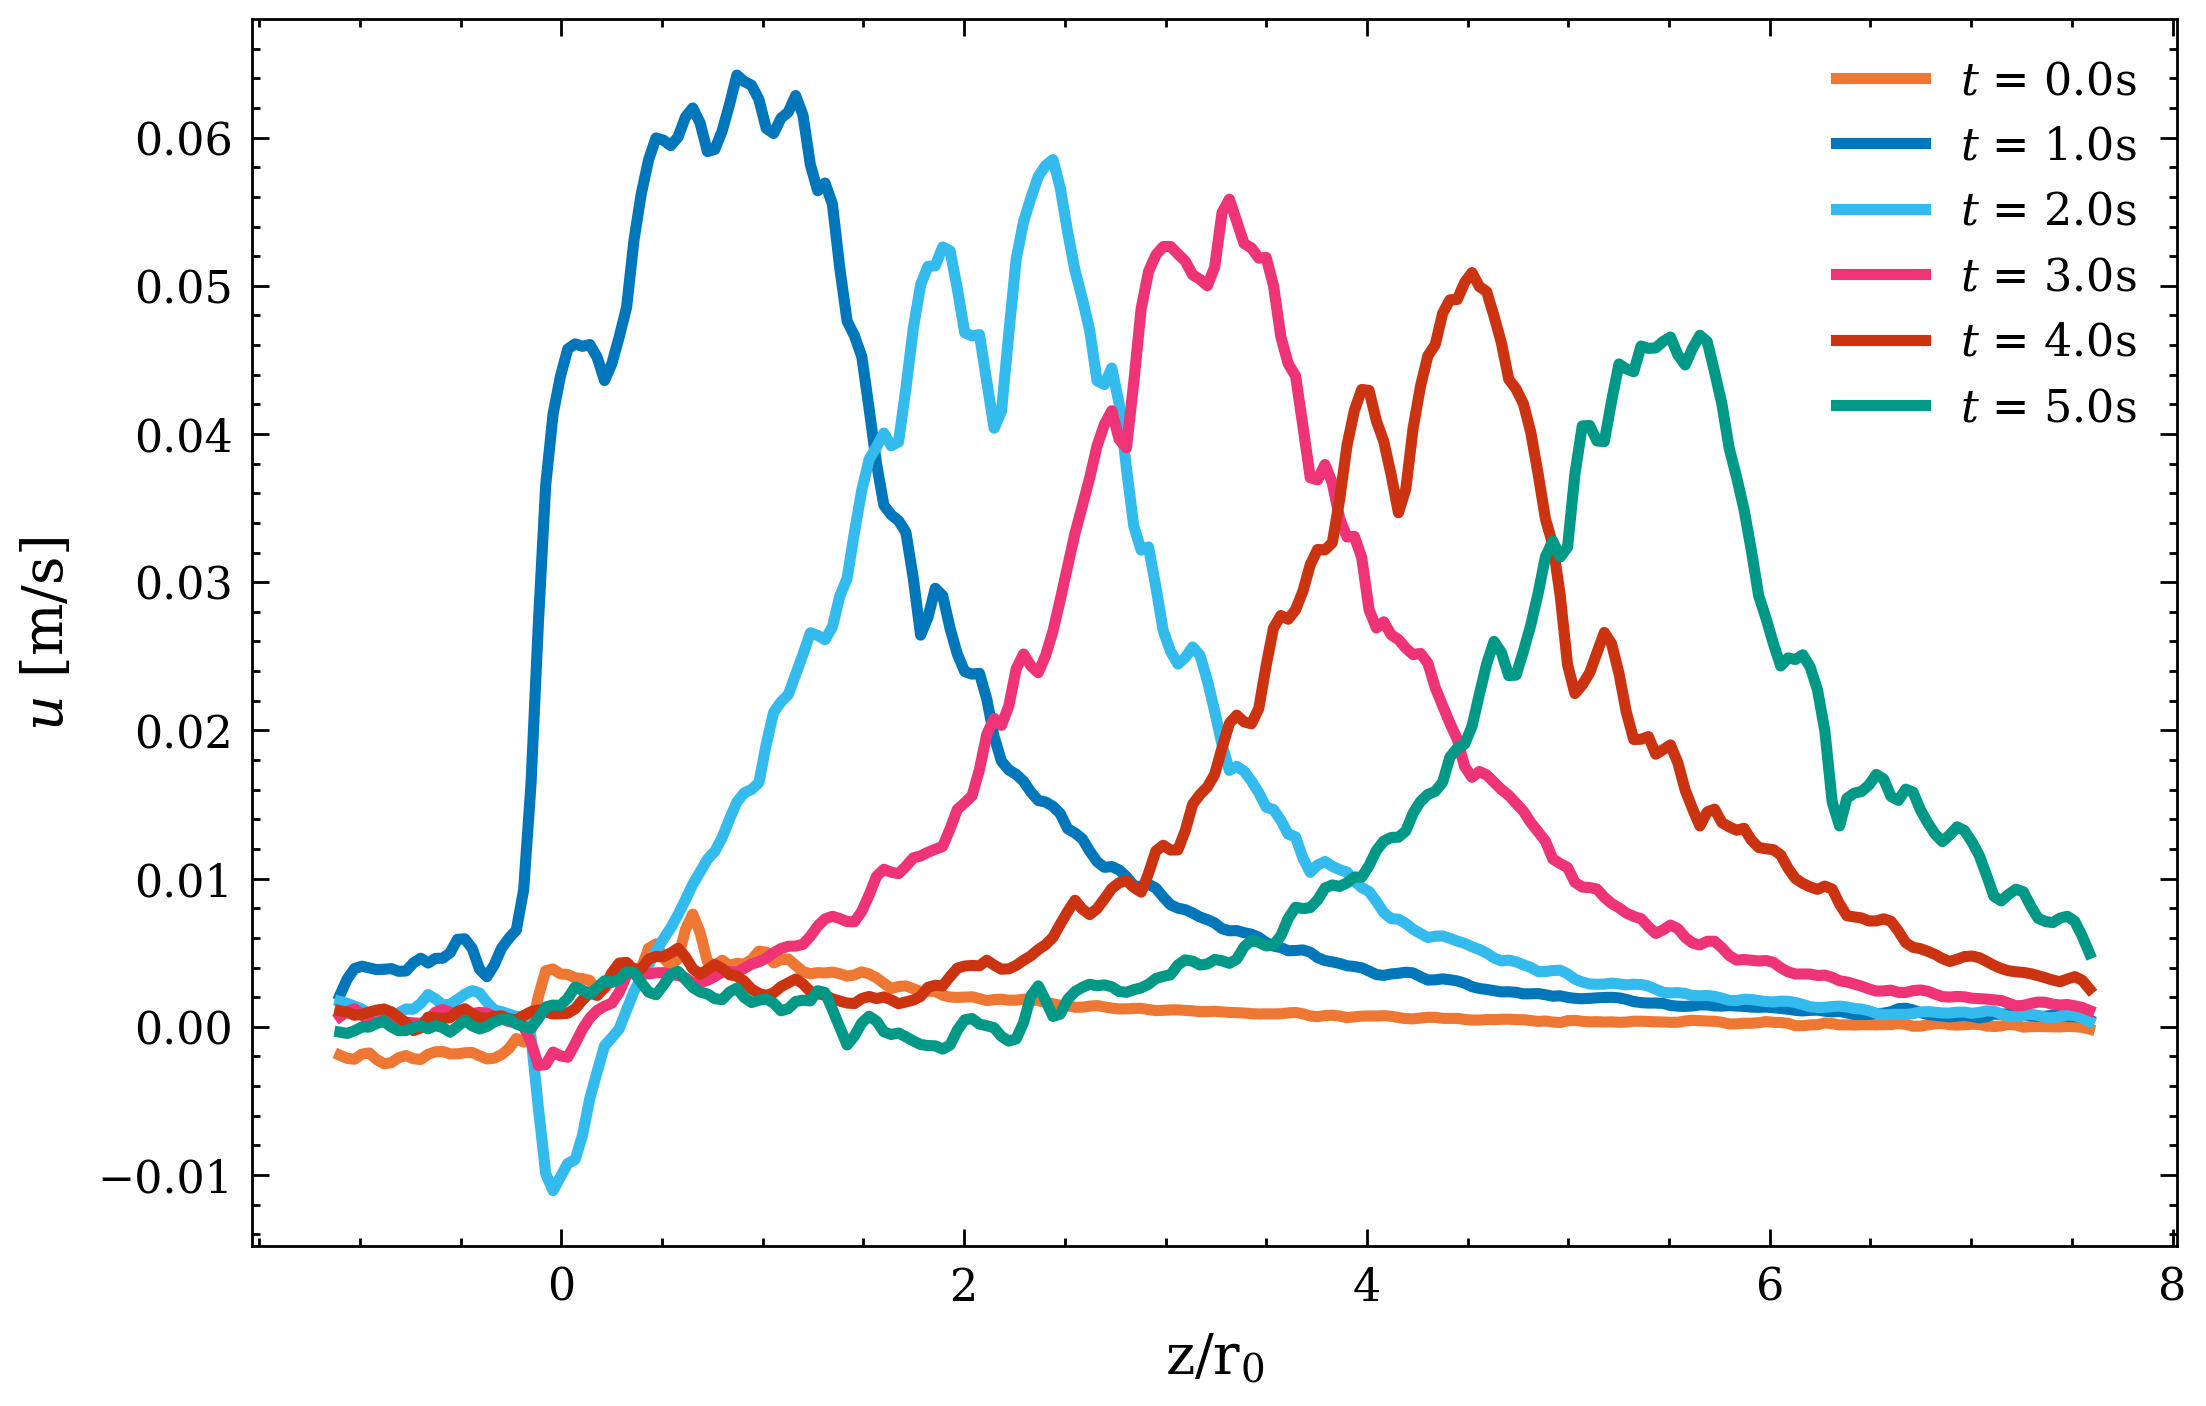

In [2]:
centre = int(u.shape[1]/2)
print(centre)

f1, ax1 = plt.subplots(1, 1, figsize=(5.5, 3.5))
for frame in range(80, 620, 90):
    ax1.plot(z_nd, u[frame,centre,:], label='$t$ = ' + str(round(Time[frame-80], 2)) + 's')
ax1.set_ylabel(r'$u$ [m/s]')
ax1.set_xlabel(r'z/r$_{0}$')
ax1.legend(fontsize=8)
plt.show()

The same plot but now for all the other roation rates

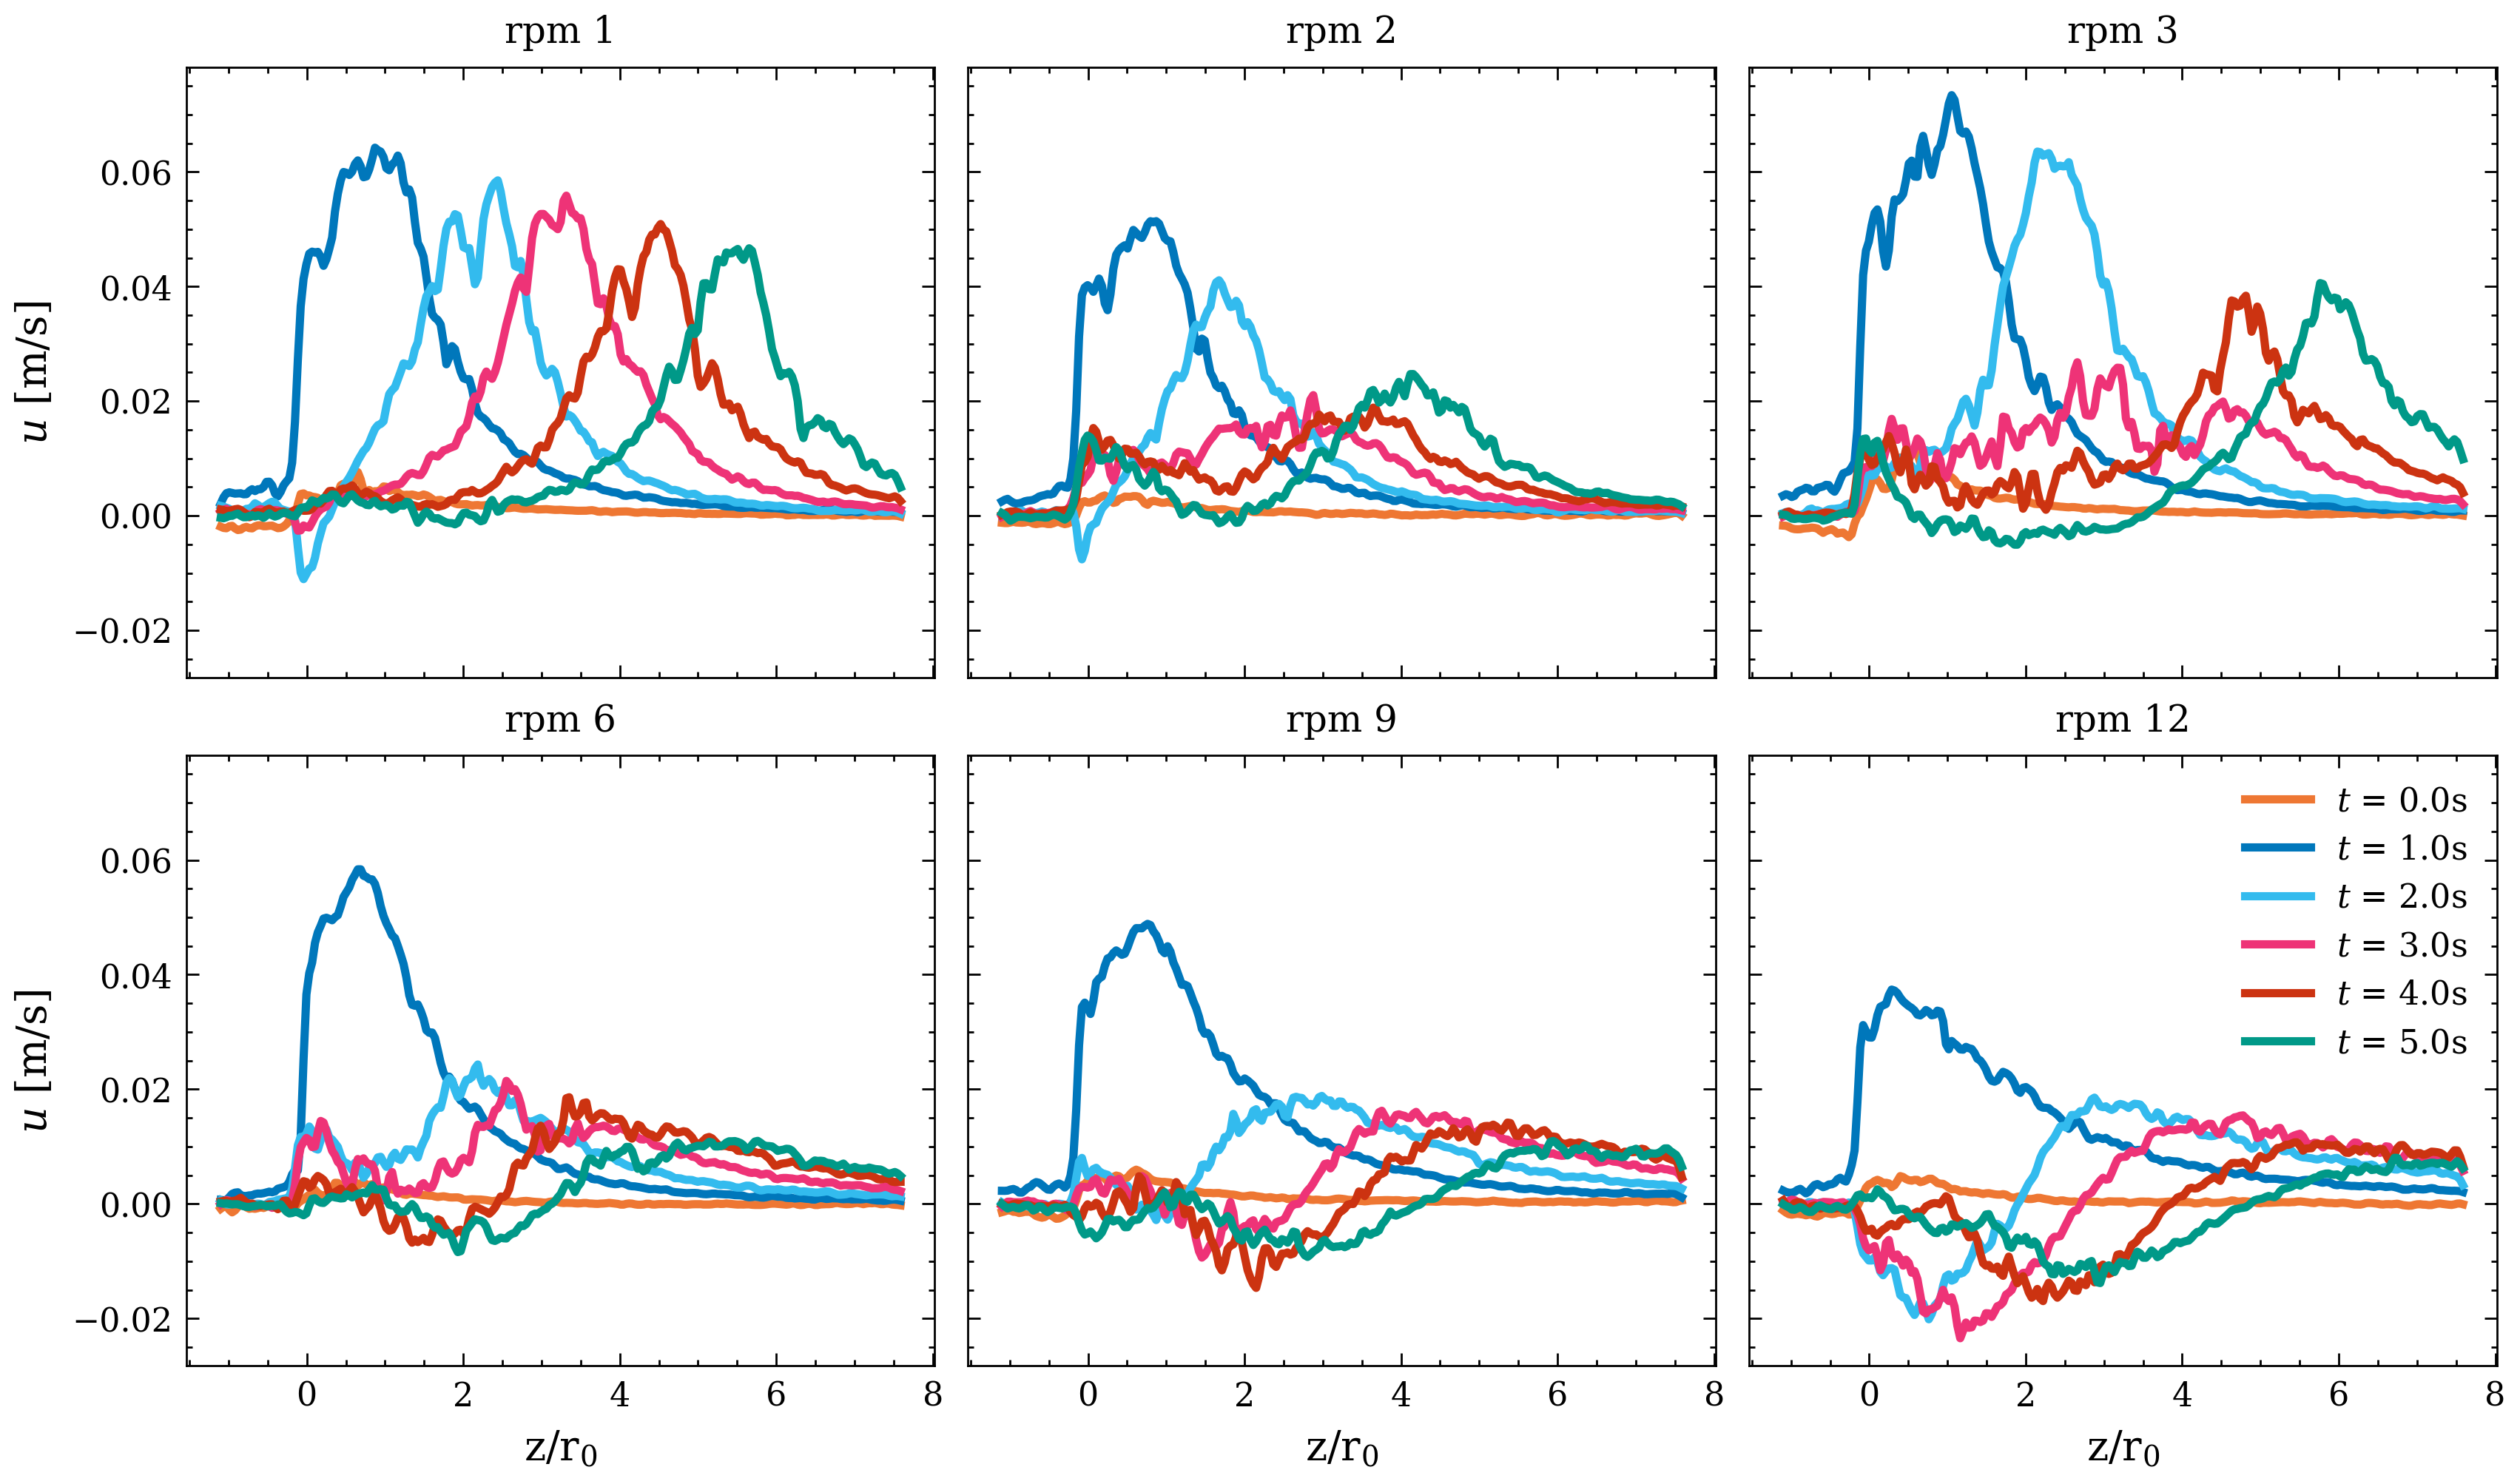

In [6]:
index = 0
rpms = [1, 2, 3, 6, 9, 12]

h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
fig, axs = plt.subplots(2, 3,sharex=True, sharey=True, figsize=(8.5, 5))
for i in range(2):
    for j in range(3):

        vels = h5file['Narrow']['U100']['L100'][f'RPM{str(rpms[index])}']
        u = vels[:,:,:,0]
        v = vels[:,:,:,1]
        u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data


        for frame in range(80, 620, 90):
            ax = axs[i, j]
            ax.plot(z_nd, u[frame,centre,:], label='$t$ = ' + str(round(Time[frame-80], 2)) + 's')
            ax.set_title(f"rpm {rpms[index]}", size=9)
        index += 1
axs[0, 0].set_ylabel(r'$u$ [m/s]')
axs[1, 0].set_ylabel(r'$u$ [m/s]')
axs[1, 0].set_xlabel(r'z/r$_{0}$')
axs[1, 1].set_xlabel(r'z/r$_{0}$')
axs[1, 2].set_xlabel(r'z/r$_{0}$')
axs[1, 2].legend(fontsize=8)
plt.show()
h5file.close()

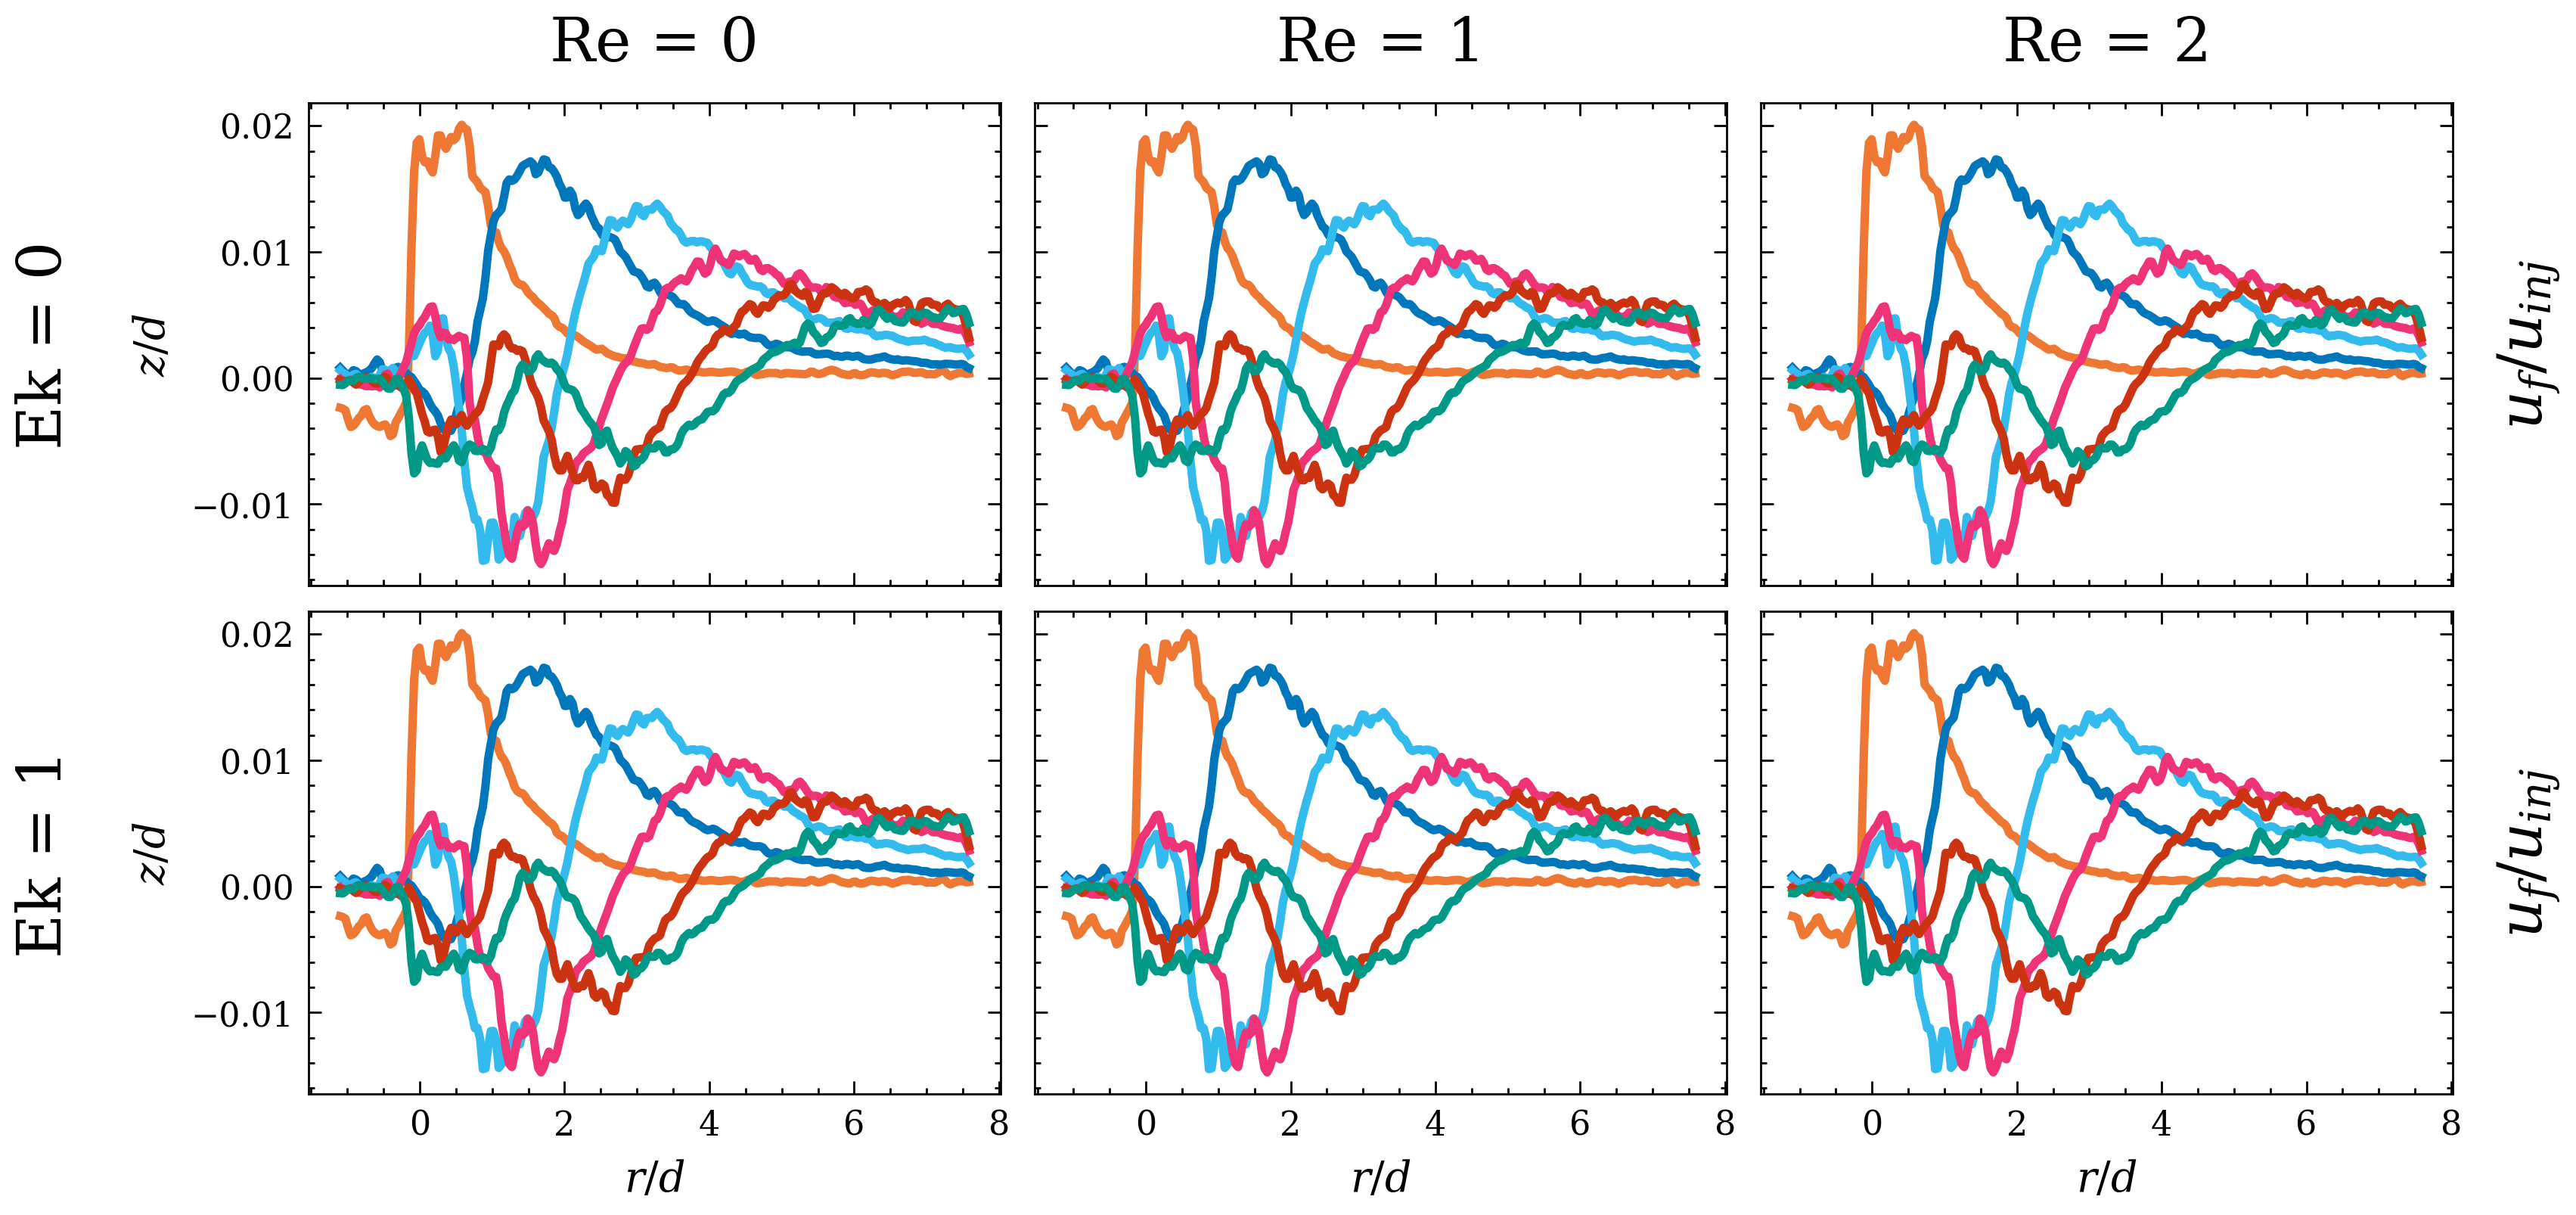

In [ ]:
def GenPlotMulti(nrows, ncols, xlabel=r'$r / d$', ylabel=r"$z / d$", cols = [0, 1, 2, 3, 4, 5, 6], rows = [0, 1, 2, 3, 4, 5, 6]):
    f, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8.5, 4), sharex = 'all', sharey = 'all')

    pad = 10

    for ax, col in zip(axs[0], cols):
        ax.annotate('Re = {}'.format(col), xy=(0.5, 1), xytext=(0, pad),
            xycoords='axes fraction', textcoords='offset points',
            size='large', ha='center', va='baseline')

    for ax, row in zip(axs[:,0], rows):
        ax.annotate('Ek = {}'.format(row), xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
            xycoords=ax.yaxis.label, textcoords='offset points', rotation= 90,
            size='large', ha='right', va='center')
        
    for ax, row in zip(axs[:,-1], rows):
        ax.annotate(r'$u_{f} / u_{inj}$', xy=(1, 0.5), xytext=(pad, 0),
            xycoords='axes fraction', textcoords='offset points', rotation= 90,
            size='large', ha='left', va='center')
        
    plt.setp(axs[-1, :], xlabel=xlabel)
    plt.setp(axs[:, 0], ylabel=ylabel)
    

    return f, axs



f, axs = GenPlotMulti(2, 3)
for i in range(2):
    for j in range(3):
        for frame in range(80, 620, 90):
            ax = axs[i, j]
            ax.plot(z_nd, u[frame,centre,:], label='$t$ = ' + str(round(Time[frame-80], 2)) + 's')
            # ax.set_title(f"Subplot {i+1}, {j+1}")
# axs[1,2].legend(fontsize=8)